<a href="https://colab.research.google.com/github/Ali13fffff/bank-customer-churn-analysis/blob/main/customer_churn_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Churn_Modelling.csv to Churn_Modelling.csv


Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load Data

In [ ]:
df=pd.read_csv("Churn_Modelling.csv")
print(df.info())
print(df.head())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1   

#Cleaning Data

In [ ]:
df=df.drop(columns=["RowNumber","CustomerId","Surname"])
df.drop_duplicates(inplace=True)
print(df.isnull().sum())

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


#Overall Data Analysis

In [ ]:

churn_percent = df["Exited"].value_counts(normalize=True) * 100
print(churn_percent)
balance_mean = df.groupby("Exited")["Balance"].mean()
print(balance_mean)

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64
Exited
0    72745.296779
1    91108.539337
Name: Balance, dtype: float64


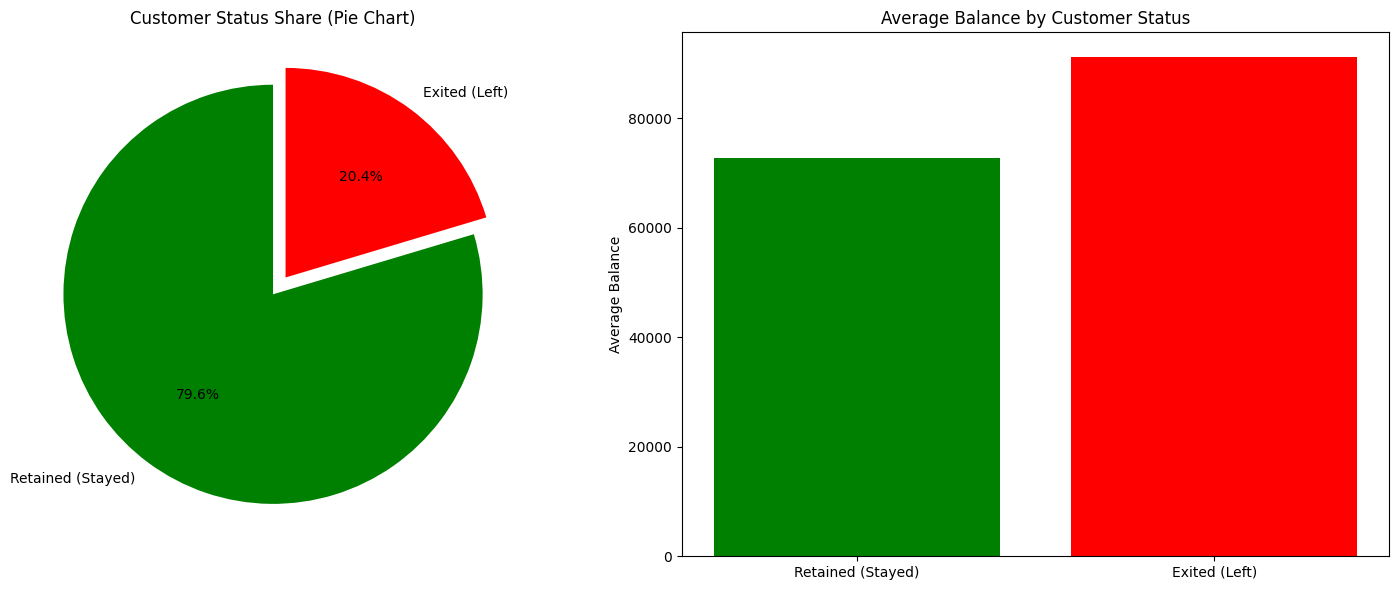

In [ ]:



exited_counts = df["Exited"].value_counts().sort_index()
balance_mean = df.groupby("Exited")["Balance"].mean().sort_index()

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.pie(
    exited_counts,
    labels=["Retained (Stayed)", "Exited (Left)"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["Green", "Red"],
    explode=(0, 0.1)
)
plt.title("Customer Status Share (Pie Chart)")

plt.subplot(1, 2, 2)
plt.bar(
    ["Retained (Stayed)", "Exited (Left)"],
    balance_mean.values,
    color=["Green", "Red"]
)
plt.title("Average Balance by Customer Status")
plt.ylabel("Average Balance")
plt.tight_layout()
plt.show()

#Around 79.6% of customers stayed with the bank, while 20.4% churned. Although the churn rate does not seem alarming at first, churned customers had a higher average balance than retained customers. This suggests the bank may be losing more valuable customers, making churn a more important business issue than the percentage alone indicates.